In [68]:

from qiskit import QuantumCircuit
from qiskit.algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import LinearAmplitudeFunction
from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import NormalDistribution, LogNormalDistribution
import numpy as np
import pandas as pd
from joblib import dump, load
from datetime import datetime
import os
from os import path
from ansys.mapdl.core import launch_mapdl, launcher, Mapdl
from ansys.mapdl import reader as mapdl_reader
from shutil import copyfile
# Quantum 0.1 minimum Obs: 0.02945089526474476, Actual f(x): 0.025705348700284958, uncertainty: 0.029140550643205643, Used Queries: 308.0

import numpy as np
from qiskit_finance.circuit.library import LogNormalDistribution


# number of qubits to represent the uncertainty
num_uncertainty_qubits = 3

# parameters for considered random distribution
S = 2.0  # initial spot price
vol = 0.4  # volatility of 40%
r = 0.05  # annual interest rate of 4%
T = 40 / 365  # 40 days to maturity

# resulting parameters for log-normal distribution
mu = 0.6
stddev = 0.1

# lowest and highest value considered for the spot price; in between, an equidistant discretization is considered.
low = mu - 3 * stddev
high = mu + 3 * stddev

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
uncertainty_model = NormalDistribution(
    num_uncertainty_qubits, mu=mu, sigma=stddev**2, bounds=(low, high)
)

f_min = low
f_max = high
slopes = 1
offsets = 0

linearpayoff = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
)

num_payoff_qubits = linearpayoff.num_qubits

monte_carlo = QuantumCircuit(num_payoff_qubits)
monte_carlo.append(uncertainty_model, range(num_uncertainty_qubits))
monte_carlo.append(linearpayoff, range(num_payoff_qubits))

objective_qubits = [0,1,2,3]
seed = 0
eps = 0.005
epsilon = np.clip(eps / (3 * stddev), 1e-6, 0.5)
# epsilon = 0.05

alpha = 0.05

max_shots = 3000

# construct estimation problem. post_processing is the inverse of the rescaling, i.e., it maps the [0, 1] interval to the original one.
# objective_qubits is the list of qubits that are used to encode the objective function.
# problem is the estimation problem that is passed to the QAE algorithm.
problem = EstimationProblem(state_preparation=monte_carlo, objective_qubits=objective_qubits, post_processing=linearpayoff.post_processing)
# construct amplitude estimation

ae = IterativeAmplitudeEstimation(epsilon_target=epsilon, alpha=alpha, sampler=Sampler(run_options={
                "shots": int(np.ceil(max_shots)), "seed_simulator": 0}))

# Running result
result = ae.estimate(problem)
obs = result.estimation_processed

print(result.num_oracle_queries)
print(obs)

30000
0.4097593135364753


In [69]:
result.estimation

0.0019510474935930948

In [71]:
from qiskit_aer.primitives import Sampler

# 复制电路（不要破坏 monte_carlo 原始版本）
qc = monte_carlo.copy()
qc.measure_all()  # 必须加测量才可以采样

shots = 3000

sampler = Sampler(run_options={
                "shots": int(np.ceil(max_shots)), "seed_simulator": 0})
results = sampler.run(qc, shots=shots).result()

# 拿到 quasi 概率分布（伪 counts）
qd = results.quasi_dists[0]

num_qubits = qc.num_qubits

print("--- bitstrings ---")
for outcome in qd.keys():
    # outcome 是整数，把它转成 qubit 对应的二进制bitstring
    bitstr = format(outcome, f"0{num_qubits}b")  # [::-1] 变成 Qiskit 的小端顺序
    print(bitstr)

--- bitstrings ---
0000
1101
1000
0110
0100
1110
0010
0111
0011
1011
1010
1111
0001
0101
1001
1100


In [75]:
qd

{0: 0.003,
 13: 0.017666666666666667,
 8: 0.0026666666666666666,
 6: 0.024,
 4: 0.30133333333333334,
 14: 0.010333333333333333,
 2: 0.12933333333333333,
 7: 0.0013333333333333333,
 3: 0.30766666666666664,
 11: 0.0036666666666666666,
 10: 0.018666666666666668,
 15: 0.002,
 1: 0.022,
 5: 0.14333333333333334,
 9: 0.009,
 12: 0.004}

In [76]:
# 打印理论概率分布 (High resolution)
from qiskit_finance.circuit.library import NormalDistribution

# number of qubits to represent the uncertainty
num_uncertainty_qubits = 3

# resulting parameters for log-normal distribution
mu = 0.6
stddev = 0.1

# lowest and highest value considered for the spot price; in between, an equidistant discretization is considered.
low = mu - 3 * stddev
high = mu + 3 * stddev

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
dist = NormalDistribution(
    num_uncertainty_qubits, mu=mu, sigma=stddev**2, bounds=(low, high)
)
probs = dist.probabilities   # 这是归一化后的分布

print("--- 理论 PDF ---")
for p in probs:
    print(p)

--- 理论 PDF ---
0.003800294724205468
0.034437987930010135
0.14968723398700332
0.31207448335878124
0.31207448335878124
0.1496872339870031
0.034437987930010135
0.003800294724205468


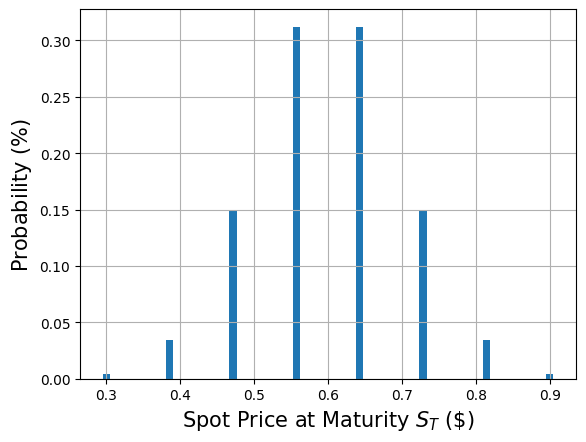

In [67]:
import matplotlib.pyplot as plt
x = uncertainty_model.values
y = uncertainty_model.probabilities
plt.bar(x, y, width=0.01)
plt.grid()
plt.xlabel("Spot Price at Maturity $S_T$ (\$)", size=15)
plt.ylabel("Probability ($\%$)", size=15)
plt.show()

In [99]:
x

array([0.3       , 0.38571429, 0.47142857, 0.55714286, 0.64285714,
       0.72857143, 0.81428571, 0.9       ])

#### 111

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import NormalDistribution
from qiskit.circuit.library import LinearAmplitudeFunction
from qiskit import QuantumCircuit

# --- Parameters ---
mean = 10
stddev = 0.1
eps = 0.01
alpha = 0.05
num_uncertainty_qubits = 6
low = mean - 3 * stddev
high = mean + 3 * stddev

# Build the uncertainty model (normal distribution)
uncertainty_model = NormalDistribution(
    num_uncertainty_qubits,
    mu=mean,
    sigma=stddev**2,
    bounds=(low, high)
)

c_approx = 1
slopes = 1
offsets = 0

f_min = low
f_max = high #change

# The LinearAmplitudeFunction is a piecewise linear function
linear_payoff = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    rescaling_factor=c_approx,
)
objective_qubits = [0]
# Build state preparation circuit
num_qubits = linear_payoff.num_qubits
monte_carlo = QuantumCircuit(num_qubits)
monte_carlo.append(uncertainty_model, range(num_uncertainty_qubits))
monte_carlo.append(linear_payoff, range(num_qubits))

# monte_carlo = linear_payoff.compose(uncertainty_model, front=True)

# Problem definition
eps = eps / (3 * stddev)
epsilon = np.clip(eps ,1e-6, 0.5)

max_shots = 100
problem = EstimationProblem(
    state_preparation=monte_carlo,
    objective_qubits=objective_qubits,
    post_processing=linear_payoff.post_processing
)
seed = 0
# Sampler and IAE setup
sampler = Sampler(run_options={"shots": max_shots, "seed_simulator":seed})

iae = IterativeAmplitudeEstimation(epsilon_target=epsilon, alpha=alpha, sampler=sampler)

# --- Run IAE 400 times ---
results = []
num_trials = 1

print("Running IAE 400 times...")
for i in range(num_trials):
    result = iae.estimate(problem)
    print(result)
    results.append(result.estimation)


In [ ]:
import torch
values = torch.linspace(-0.2, 0.2, 5)
# Generate Cartesian product for variable dimensions only (first two and last two)
variable_dims = torch.cartesian_prod(values, values, values, values, values, values, values, values)

# Number of combinations in variable_dims
num_combinations = variable_dims.shape[0]

# Fixed value tensor
fixed_values = torch.zeros(num_combinations, 10)  # 12 fixed dimensions

# Place variable dimensions at the positions they need to be, which are first two and last two in your case
search_space = torch.cat([
    variable_dims[:, :4],  # First two variable dimensions
    fixed_values,          # Twelve fixed dimensions initialized to 0.0
    variable_dims[:, 4:]   # Last two variable dimensions
], dim=1)

In [ ]:
from math import log, ceil, sqrt
from statistics import mean, pstdev
from typing import Callable, Tuple, Optional, List
import random
import numpy as np

def monte_carlo_estimate(
    draw: Callable[[], float],
    epsilon: float,
    var: float,
    delta: float = 0.05,
    method: str = "hoeffding",
    min_batch: int = 100,
    max_samples: Optional[int] = None,
) -> Tuple[float, int]:
    """
    Estimate E[X] with additive error <= epsilon with probability >= 1 - delta.

    Parameters
    ----------
    draw : Callable[[], float]
        A function that returns one i.i.d. sample X.
        For 'hoeffding' you should ensure X ∈ [0, 1] (or scale it).
    epsilon : float
        Target absolute error tolerance.
    delta : float, default 0.05
        Failure probability (1 - confidence).
    method : {'hoeffding', 'clt'}, default 'hoeffding'
        - 'hoeffding': fixed-sample bound assuming X ∈ [0, 1].
        - 'clt': sequential stopping using a (robust) CI from the central limit theorem.
    min_batch : int, default 100
        Batch size to sample at a time for the 'clt' method.
    max_samples : Optional[int], default None
        Safety cap on the total samples. If None, unlimited.

    Returns
    -------
    mu_hat : float
        The Monte Carlo estimate of the mean.
    n : int
        The total number of queries (samples) used.
    """
    if epsilon <= 0:
        raise ValueError("epsilon must be positive")
    if not (0 < delta < 1):
        raise ValueError("delta must be in (0,1)")
    if method not in {"hoeffding", "clt", "chebyshev"}:
        raise ValueError("method must be 'hoeffding' or 'clt'")

    # Method 1: Distribution-free fixed-N via Hoeffding (assumes X ∈ [0,1])
    if method == "hoeffding":
        # n >= (1/(2*epsilon^2)) * ln(2/delta)
        # n_required = ceil((1/(2*epsilon**2)) * log(2/delta))
        n_required = ceil((18 * var / (1.0 * (epsilon ** 2))) * log(2.0 / delta))
        if max_samples is not None:
            n_required = min(n_required, max_samples)
        samples = [draw() for _ in range(n_required)]
        return (sum(samples) / n_required, n_required)
    
    if method == 'chebyshev':
        # n_total = 0
        # samples: List[float] = []
        # batch = [draw() for _ in range(min_batch)]
        # samples.extend(batch)
        # n_total += len(batch)

        # mu_hat = sum(samples) / n_total
        # # population std is unknown; use sample std (with n-1) but statistics.pstdev uses population.
        # # We'll compute sample std manually to avoid SciPy:
        # if n_total > 1:
        #     m = mu_hat
        #     var = sum((x - m) ** 2 for x in samples) / (n_total - 1)
        #     s = sqrt(var)
        n_required = ceil((var/epsilon**2)*(1/delta))
        if max_samples is not None:
            n_required = min(n_required, max_samples)
        samples = [draw() for _ in range(n_required)]
        return (sum(samples) / n_required, n_required)
        

    # Method 2: Sequential CLT-based stopping (works beyond [0,1], but needs finite variance)
    samples: List[float] = []
    n_total = 0
    # z for two-sided (1 - delta) CI; use normal quantile ~1.96 for 95%,
    # or a conservative upper bound via 2.0 for simplicity.
    # If you want exact, import from scipy.stats: z = st.norm.ppf(1 - delta/2)
    def z_two_sided(d: float) -> float:
        # crude piecewise without SciPy
        if d <= 0.02:
            return 2.326347874  # ~98% CI
        if d <= 0.05:
            return 1.959963985  # ~95% CI
        if d <= 0.10:
            return 1.644853627  # ~90% CI
        if d == 0.05:
            return 1.959963985  
        return 1.281551566      # ~80% CI
    z = z_two_sided(delta)
    
    
    while True:
        # grab a batch
        batch = [draw() for _ in range(min_batch)]
        samples.extend(batch)
        n_total += len(batch)

        mu_hat = sum(samples) / n_total
        # population std is unknown; use sample std (with n-1) but statistics.pstdev uses population.
        # We'll compute sample std manually to avoid SciPy:
        if n_total > 1:
            m = mu_hat
            var = sum((x - m) ** 2 for x in samples) / (n_total - 1)
            s = sqrt(var)
        else:
            s = float("inf")

        # CI half-width ≈ z * s / sqrt(n)
        half_width = z * (s / sqrt(n_total)) if n_total > 1 else float("inf")

        # Stop when CI half-width ≤ epsilon
        if n_total > 1 and half_width <= epsilon:
            return (mu_hat, n_total)

        if max_samples is not None and n_total >= max_samples:
            return (mu_hat, n_total)

# ---------------------------
# Example usage
# ---------------------------

if __name__ == "__main__":
    # Example 1: Estimate mean of Bernoulli(p=0.37) in [0,1]
    # p = 0.5
    # def draw_bernoulli():
    #     return 1.0 if random.random() < p else 0.0

    # mu_hat, n = monte_carlo_estimate(draw_bernoulli, epsilon=0.1, delta=0.1, method="clt")
    # print(f"[clt] mean≈{mu_hat:.4f}, queries={n}")

    # Example 2: Estimate mean of a general variable (Gaussian with mean 2.0, std 3.0)
    import random
    mean_ = 10
    stddev = 0.1
    eps = 0.01
    def draw_gaussian(mean, std):
        return random.gauss(mean, std)
    
    mu_hat2, n2 = monte_carlo_estimate(draw=lambda: draw_gaussian(mean=mean_, std=stddev), epsilon=eps, delta=0.05, var=stddev**2, method="chebyshev")
    print(f"[clt] mean≈{mu_hat2:.4f}, queries={n2}")

### Binary

In [60]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.extensions import Initialize          # 老版 Qiskit 在这里
from qiskit_algorithms import EstimationProblem, IterativeAmplitudeEstimation
from qiskit_aer.primitives import Sampler

# ---------- 1) 构造骰子分布 ----------
p6 = 0.9
p_rest = np.random.rand(5)
p_rest = 0.1 * p_rest / np.sum(p_rest)          # 归一到 0.1

probs = np.concatenate((p_rest, [p6], [0, 0]))  # 8 维，对应 3 个 qubit
amps = np.sqrt(probs)

print("probs =", probs, "sum =", probs.sum())

# ---------- 2) 用 Initialize 构造 unitary state_preparation A ----------
init = Initialize(amps)

prep = QuantumCircuit(3)
# 关键：用 gates_to_uncompute().inverse() 得到只含标准门的可逆电路
prep.compose(init.gates_to_uncompute().inverse(), [0, 1, 2], inplace=True)
A_gate = prep.to_gate(label="A")   # 这是 AE 里的 A

# ---------- 3) payoff：只要 x = 101(=5，对应第 6 面) 就让 ancilla 变成 1 ----------
def payoff_indicator_six():
    qc = QuantumCircuit(4)  # 3 个状态 qubit + 1 个 ancilla

    # 我们约定：
    # qubit 顺序: [q0, q1, q2, ancilla]
    # x = 101 时希望 ancilla 变成 1
    # 也就是说：
    #   q2 q1 q0 = 1 0 1
    # 下面的写法假设你把 q0 作为 LSB，q2 作为 MSB
    qc.x(1)                 # 把中间那个 qubit 取反，让 0 变成控制条件
    qc.mcx([0, 1, 2], 3)    # 多控 X：只有 1-1-1 时 ancilla 置 1
    qc.x(1)

    return qc.to_gate(label="S_chi")

S_chi = payoff_indicator_six()

# ---------- 4) 组合成 QMC 的 A_tot 电路 ----------
qmc = QuantumCircuit(4)
qmc.append(A_gate, [0, 1, 2])          # 先制备分布
qmc.append(S_chi, [0, 1, 2, 3])        # 再根据 x 是否=6 控 ancilla=1

# 现在 qmc 就是 AE 里的 state_preparation

# ---------- 5) 定义 EstimationProblem 并运行 IAE ----------
problem = EstimationProblem(
    state_preparation=qmc,
    objective_qubits=[3],     # ancilla qubit 是“good state”的标识
)

ae = IterativeAmplitudeEstimation(
    epsilon_target=0.01,
    alpha=0.05,
    sampler=Sampler(),
)

result = ae.estimate(problem)

print("AE estimated P(6) =", result.estimation)
print("oracle queries    =", result.num_oracle_queries)
print("ratios            =", result.ratios)
print("powers            =", result.powers)

probs = [0.02869558 0.00985244 0.02559178 0.02038098 0.01547922 0.9
 0.         0.        ] sum = 1.0
AE estimated P(6) = 0.9014396446484625
oracle queries    = 5120
ratios            = [1.0, 11.0]
powers            = [0, 0, 5]


In [61]:
qmc.draw()

┌────┐┌────────┐
q_0: ┤0   ├┤0       ├
     │    ││        │
q_1: ┤1 A ├┤1       ├
     │    ││  S_chi │
q_2: ┤2   ├┤2       ├
     └────┘│        │
q_3: ──────┤3       ├
           └────────┘

In [62]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.extensions import Initialize  # 你这个版本里有

# ----- 1) 构造概率分布 -----
np.random.seed(0)

p6 = 0.9
p_rest = np.random.rand(5)
p_rest = 0.1 * p_rest / np.sum(p_rest)        # 归一化到 0.1

# probs[0..5] 对应点数 1..6；probs[6], probs[7] 用不到，设 0
probs = np.concatenate((p_rest, [p6, 0.0, 0.0]))
amps = np.sqrt(probs)
num_state_qubits = 3

print("probs (for indices 0..7) =", probs)
print("sum probs =", probs.sum())
print("True P(6) =", probs[5])
print()

# ----- 2) 用 Initialize 的“可逆版本”做 A 门 -----
init = Initialize(amps)

prep = QuantumCircuit(num_state_qubits)
# 关键：用 gates_to_uncompute().inverse() 拆成标准门，保证可逆，AE 才能用
prep.compose(init.gates_to_uncompute().inverse(), [0, 1, 2], inplace=True)
A_gate = prep.to_gate(label="A")

print(prep.draw())

probs (for indices 0..7) = [0.01935642 0.02522443 0.02125921 0.0192178  0.01494213 0.9
 0.         0.        ]
sum probs = 1.0
True P(6) = 0.9

                                                        »
q_0: ───────────────────────────────────────────────────»
                              ┌────────────────────────┐»
q_1: ─────────────────────────┤0                       ├»
     ┌───────────────────────┐│  multiplex2_reverse_dg │»
q_2: ┤ multiplex1_reverse_dg ├┤1                       ├»
     └───────────────────────┘└────────────────────────┘»
«     ┌────────────────────────┐
«q_0: ┤0                       ├
«     │                        │
«q_1: ┤1 multiplex3_reverse_dg ├
«     │                        │
«q_2: ┤2                       ├
«     └────────────────────────┘


In [63]:
def indicator_gate_for_index(i, num_state_qubits=3):
    """
    构造：当且仅当 (q2 q1 q0) 对应的整数为 i 时，把 ancilla 置 1 的电路。
    qubit 布局： [q0, q1, q2, ancilla]
    """
    from qiskit import QuantumCircuit

    qc = QuantumCircuit(num_state_qubits + 1)  # +1 个 ancilla

    # 把 i 转成长度=3 的二进制串（LSB 在前）
    bits = [(i >> j) & 1 for j in range(num_state_qubits)]  # [b0, b1, b2]

    # 对于那些 bit=0 的 qubit，先 X 一下，变成 1
    for q, bit in enumerate(bits):
        if bit == 0:
            qc.x(q)

    # 多控 X：所有控制位是 1 时，翻转 ancilla
    qc.mcx(list(range(num_state_qubits)), num_state_qubits)

    # 再把那些 bit=0 的位置 X 回去
    for q, bit in enumerate(bits):
        if bit == 0:
            qc.x(q)

    return qc.to_gate(label=f"chi_{i}")

from qiskit_algorithms import EstimationProblem, IterativeAmplitudeEstimation
from qiskit_aer.primitives import Sampler

sampler = Sampler()
ae = IterativeAmplitudeEstimation(
    epsilon_target=0.01,   # 误差目标
    alpha=0.05,            # 置信水平 95%
    sampler=sampler,
)

def estimate_prob_of_face(k):
    """
    用 AE 估计 P(X = k)，其中 k in {1,...,6}.
    映射：face k ↔ index i = k-1 (0..5)
    """
    i = k - 1  # index 0..5
    ind_gate = indicator_gate_for_index(i, num_state_qubits)

    # 3 个状态 qubit + 1 个 ancilla
    qc = QuantumCircuit(num_state_qubits + 1)
    qc.append(A_gate, range(num_state_qubits))
    qc.append(ind_gate, range(num_state_qubits + 1))

    problem = EstimationProblem(
        state_preparation=qc,
        objective_qubits=[num_state_qubits],  # ancilla 的 index = 3
    )

    result = ae.estimate(problem)
    queries = result.num_oracle_queries
    return result.estimation, queries  # 这里就是 ~ P(X=k)

# 估计每个点的概率
est_probs = []
for k in range(1, 7):
    p_hat, queries = estimate_prob_of_face(k)
    print(queries)
    est_probs.append(p_hat)
    print(f"AE estimated P(X={k}) = {p_hat:.4f}")
    
    

print("\nSum of estimated probs =", sum(est_probs))

# 用 AE 结果计算期望
E_hat = sum((k) * est_probs[k-1] for k in range(1, 7))
print(f"\nAE estimated E[X] = {E_hat:.4f}")

# 真实期望(用我们构造的 probs 计算)
true_probs_faces = probs[:6]            # index 0..5 对应 1..6
true_EX = sum((k) * true_probs_faces[k-1] for k in range(1, 7))
print(f"True E[X]         = {true_EX:.4f}")

4096
AE estimated P(X=1) = 0.0190
6144
AE estimated P(X=2) = 0.0254
6144
AE estimated P(X=3) = 0.0212
3072
AE estimated P(X=4) = 0.0187
4096
AE estimated P(X=5) = 0.0147
8192
AE estimated P(X=6) = 0.9003

Sum of estimated probs = 0.999307431273211

AE estimated E[X] = 5.6837
True E[X]         = 5.6852


In [64]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit import execute

# ---------- 1) 用你之前构造好的 A_gate ----------
# 假设你已经有:
#   - num_state_qubits = 3
#   - A_gate = 预先构造的制备分布的 gate
#   - probs = 你构造的真实概率（用于对比）

# 构造只做 state preparation + 测量的电路
qmc_mc = QuantumCircuit(num_state_qubits)
qmc_mc.append(A_gate, range(num_state_qubits))
qmc_mc.measure_all()

# ---------- 2) 经典 Monte Carlo 仿真 ----------
backend = Aer.get_backend('qasm_simulator')
shots = 100

job = execute(qmc_mc, backend=backend, shots=shots)
result = job.result()
counts = result.get_counts()

# ---------- 3) 把 bitstring 统计转换成 6 个点的概率 ----------
# 映射：index 0..5 ↔ 点数 1..6
# 假设比特顺序是 q2 q1 q0（看你之前怎么画电路的）
p_est = np.zeros(6)

for bitstring, c in counts.items():
    # bitstring 例如 '101'，最低位在右边
    idx = int(bitstring, 2)  # 0..7
    if 0 <= idx <= 5:        # 只用 6 个状态
        face = idx + 1       # 1..6
        p_est[face - 1] += c

p_est = p_est / shots

print("=== Monte Carlo estimated P(X=k) ===")
for k in range(1, 7):
    print(f"P(X={k}) ≈ {p_est[k-1]:.4f}")
print("sum P =", p_est.sum())

# ---------- 4) 一次性输出期望 E[X] ----------
faces = np.arange(1, 7)
E_hat = np.sum(faces * p_est)

print("\nEstimated E[X] =", E_hat)

=== Monte Carlo estimated P(X=k) ===
P(X=1) ≈ 0.0300
P(X=2) ≈ 0.0100
P(X=3) ≈ 0.0100
P(X=4) ≈ 0.0000
P(X=5) ≈ 0.0100
P(X=6) ≈ 0.9400
sum P = 1.0

Estimated E[X] = 5.77


### option


In [ ]:

from qiskit.circuit.library import RYGate
num_uncertainty_qubits = 1

p = 0.2

low = 0
high = 1

# Calculate the rotation angle
theta = 2 * np.arcsin(np.sqrt(p))
# Create a quantum circuit
qc = QuantumCircuit(num_uncertainty_qubits)

# Apply the RY rotation
qc.append(RYGate(theta), [0])
uncertainty_model = qc

monte_carlo = uncertainty_model

epsilon = eps

objective_qubits = [0]
seed = 0

epsilon = np.clip(epsilon, 1e-6, 0.5)

alpha = 0.05
max_shots = 32 * np.log(2/alpha*np.log2(np.pi/(4*epsilon))) 
    
post_processing = lambda x: x

problem = EstimationProblem(
    state_preparation=monte_carlo,
    objective_qubits=objective_qubits,
    post_processing=post_processing,)


ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=Sampler(run_options={"shots": int(np.ceil(max_shots)),"seed_simulator":seed}))

# Running result
result = ae.estimate(problem)

est = result.estimation_processed

In [ ]:
print(est)